# Manchester Encoding with Plotting

In [9]:
import matplotlib.pyplot as plt

bits = "10110010"

In [10]:
# --------------------------------
# Manchester Encoding function
# IEEE Convention:
# 0 -> High to Low
# 1 -> Low to High
# --------------------------------

def manchester(bits):
    signal = []
    for bit in bits:
        if bit == "0":
            signal.extend([1, -1])
        else:
            signal.extend([-1, 1])
    return signal

In [11]:
# Generating Manchester signal
signal = manchester(bits)

print("Bit Stream        :", bits)
print("\nManchester Signal :", signal)

Bit Stream        : 10110010

Manchester Signal : [-1, 1, 1, -1, -1, 1, -1, 1, 1, -1, 1, -1, -1, 1, 1, -1]


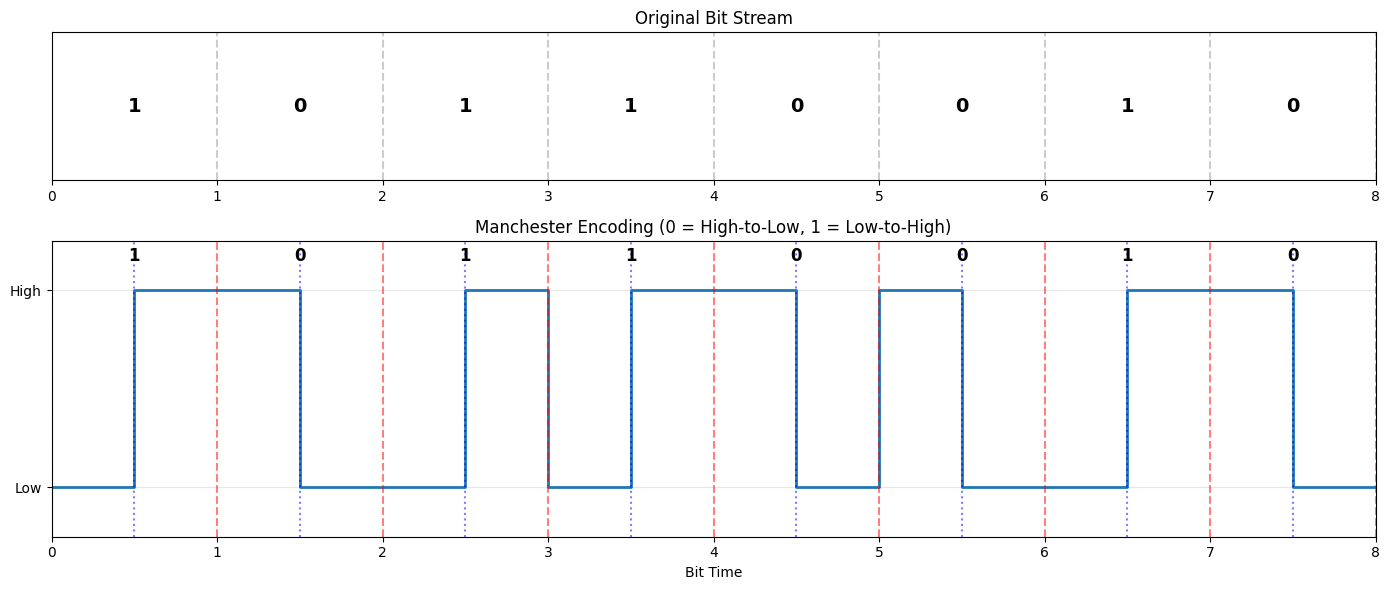

In [16]:
# Creating subplots
fig, axes = plt.subplots(2, 1, 
                        figsize=(14, 6), 
                        gridspec_kw = {'height_ratios': [1,2]}
                        )

# Plot original bits

axes[0].set_xlim(0, len(bits))
axes[0].set_ylim(-1,1)

for i,bit in enumerate(bits):
    axes[0].text(i+0.5, 0, bit, ha='center', va='center', fontsize = 14, fontweight='bold')
    axes[0].axvline(i, color='gray', linestyle='--', alpha=0.4)
    
axes[0].axvline(len(bits), color='gray', linestyle='--', alpha=0.4)      # n+1 boundary lines for n bits

axes[0].set_yticks([])      # tells matplotlib not to show any tick on y-axis
axes[0].set_title("Original Bit Stream")



# PLot Manchester signal

t = []
for i in range(len(signal)):
    start = i / 2
    end = (i+1) / 2
    t.extend([start, end])

y = []
for value in signal:
    y.extend([value, value])

axes[1].plot(t, y, drawstyle='steps-post', linewidth=2)

# Bit boundaries
for i in range(len(bits) + 1):
    axes[1].axvline(i, color='red', linestyle='--', alpha=0.5)

# Middle of the bit transition
for i in range(len(bits)):
    axes[1].axvline(i+0.5, color='blue', linestyle=':', alpha=0.5)

# Bit labels
for i,bit in enumerate(bits):
    axes[1].text(i+0.5, 1.3, bit, ha='center', fontsize=12, fontweight='bold')


axes[1].set_xlim(0, len(bits))
axes[1].set_ylim(-1.5, 1.5)

axes[1].set_yticks([-1, 1])
axes[1].set_yticklabels(['Low', 'High'])

axes[1].set_xlabel("Bit Time")
axes[1].set_title("Manchester Encoding (0 = High-to-Low, 1 = Low-to-High)")

axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()